In [ ]:
#23.1
import folium
m=folium.Map(location=[10.761242912267818, 106.66829362184478], zoom_start=14)
folium.Marker([10.761242912267818, 106.66829362184478], popup="UEH").add_to(m)
folium.Marker([10.755642756155234, 106.66441827951607], popup="Benh vien dai hoc y duoc").add_to(m)
folium.Marker([10.770739745269966, 106.67049749485923], popup="Van Hanh mall").add_to(m)
folium.Marker([10.76720046811694, 106.65870099485919], popup="San van dong Phu Tho").add_to(m)
folium.Marker([10.762587832449114, 106.67031037156738], popup="Trung tam y khoa Hoa Hao").add_to(m)
m

In [ ]:
#23.2
from geopy.geocoders import Nominatim
from geopy.distance import geodesic
import folium
geolocator=Nominatim(user_agent='geoapi')
center_name="Đại học Kinh Tế TP.HCM"
center_loc=geolocator.geocode(center_name)
center=(center_loc.latitude, center_loc.longitude)

m=folium.Map(location=[center_loc.latitude, center_loc.longitude], zoom_start=13)

addresses=["Chợ Bến Thành, TP.HCM",
           "Bệnh viện Chợ Rẫy, TP.HCM",
           "Dinh Độc Lập, TP.HCM ",
           "Nhà thờ Đức Bà, TP.HCM",
           "Thảo Cầm Viên, TP.HCM",
           "Phố đi bộ Bùi Viện, TP.HCM"
           "Nhà hát Hòa Bình, TP.HCM",
           "Bệnh viện Đại học Y Dược, TP.HCM",
           "Bến xe Miền Tây, TP.HCM",
           "Vạn Hạnh Mall, TP.HCM"]
for adr in addresses:
  loc=geolocator.geocode(adr)
  if loc:
    coord=(loc.latitude, loc.longitude)
    dist=geodesic(center, coord).km
    print(f"Khoảng cách từ {adr} đến {center_name} là: {round(dist, 2)} km")
    folium.Marker(coord, popup=adr).add_to(m)
    folium.PolyLine([center, coord], color="red").add_to(m)
m

Khoảng cách từ Chợ Bến Thành, TP.HCM đến Đại học Kinh Tế TP.HCM là: 3.47 km
Khoảng cách từ Bệnh viện Chợ Rẫy, TP.HCM đến Đại học Kinh Tế TP.HCM là: 1.08 km
Khoảng cách từ Dinh Độc Lập, TP.HCM  đến Đại học Kinh Tế TP.HCM là: 3.44 km
Khoảng cách từ Nhà thờ Đức Bà, TP.HCM đến Đại học Kinh Tế TP.HCM là: 3.91 km
Khoảng cách từ Thảo Cầm Viên, TP.HCM đến Đại học Kinh Tế TP.HCM là: 5.05 km
Khoảng cách từ Bệnh viện Đại học Y Dược, TP.HCM đến Đại học Kinh Tế TP.HCM là: 0.73 km
Khoảng cách từ Bến xe Miền Tây, TP.HCM đến Đại học Kinh Tế TP.HCM là: 5.85 km
Khoảng cách từ Vạn Hạnh Mall, TP.HCM đến Đại học Kinh Tế TP.HCM là: 1.05 km


In [ ]:
#23.3
import folium
from folium.plugins import HeatMap
points = [
    [10.776, 106.700],
    [10.775, 106.699],
    [10.774, 106.701],
    [10.773, 106.698],
    [10.772, 106.702],
    [10.771, 106.700],
]

m = folium.Map(location=[10.774, 106.700], zoom_start=14)
HeatMap(points).add_to(m)
m

In [ ]:
#23.4
import geopandas as gpd
import pandas as pd
import folium
gdf = gpd.read_file("district-boundary-hcm-city.geojson")
df = pd.read_csv("hcm_district_data.csv")
for feature in geo["features"]:
    feature.pop("timestamp", None)
    feature["properties"].pop("timestamp", None)

m = folium.Map(location=[10.78, 106.68], zoom_start=11)

folium.Choropleth(
    geo_data=geo,
    data=df,
    columns=["district", "sales"],
    key_on="feature.properties.localname",
    fill_color="YlOrRd",
    fill_opacity=0.7,
    line_opacity=0.2,
    legend_name="Doanh số"
).add_to(m)
m

In [ ]:
#23.5
import folium
m=folium.Map(location=[10.761242912267818, 106.66829362184478], zoom_start=11)
folium.Marker([10.761242912267818, 106.66829362184478], popup="UEH").add_to(m)
for radius, color in [(3000, "green"), (5000, "orange"), (10000, "red")]:
  folium.Circle(
    location=[10.761242912267818, 106.66829362184478],
    radius=radius,
    color=color,
    fill=True,
    fill_opacity=0.1,
    popup=f"Bán kính {radius/1000} km"
  ).add_to(m)
m

In [ ]:
!uv pip install --system --quiet osmnx[all]

Số nút: 912
Số cạnh: 2142


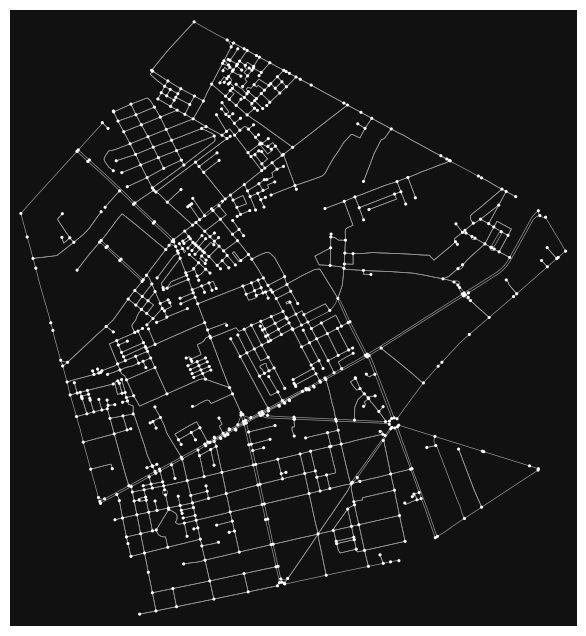

In [ ]:
#23.6
import osmnx as ox
import matplotlib.pyplot as plt

place = "District 10, Ho Chi Minh City, Vietnam"
G = ox.graph_from_place(place, network_type="drive")

print("Số nút:", len(G.nodes))
print("Số cạnh:", len(G.edges))

fig, ax = ox.plot_graph(G, node_size=5, edge_linewidth=0.5, show=False, close=False)
plt.show()

Dijkstra số nút: 41
A* số nút: 41


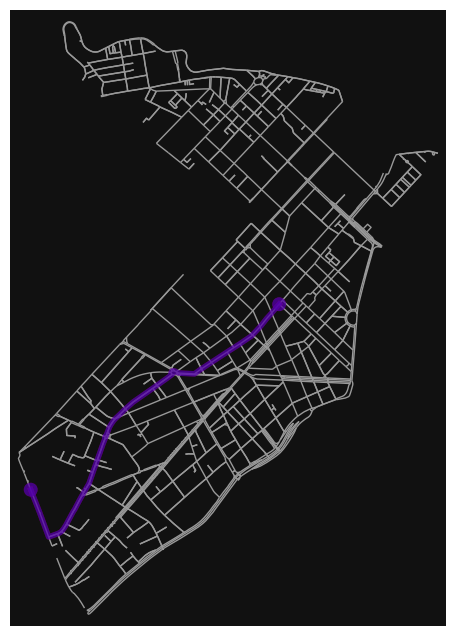

In [ ]:
#23.7
import osmnx as ox
import networkx as nx
import matplotlib.pyplot as plt
place = "District 1, Ho Chi Minh City, Vietnam"
G = ox.graph_from_place(place, network_type="drive")
G = ox.add_edge_speeds(G)
G = ox.add_edge_travel_times(G)

origin = ox.nearest_nodes(G, X=106.7009, Y=10.7765)
destination = ox.nearest_nodes(G, X=106.6822, Y=10.7629)

route_dijkstra = nx.shortest_path(G, origin, destination, weight="length")
route_astar = nx.astar_path(G, origin, destination, weight="length")

print("Dijkstra số nút:", len(route_dijkstra))
print("A* số nút:", len(route_astar))

fig, ax = ox.plot_graph_routes(
    G, [route_dijkstra, route_astar],
    route_colors=["r", "b"],
    route_linewidth=4,
    node_size=0,
    show=False,
    close=False
)
plt.show()

In [ ]:
#23.8
from geopy.distance import geodesic
import pandas as pd
import folium
drivers = {
    "Tài xế 1": (10.776, 106.700),
    "Tài xế 2": (10.800, 106.650),
    "Tài xế 3": (10.730, 106.720)
}

customers = {
    "Khách 1": (10.790, 106.663),
    "Khách 2": (10.769, 106.691),
    "Khách 3": (10.781, 106.704)
}

m = folium.Map(location=[10.775, 106.700], zoom_start=12)

for name, coord in drivers.items():
    folium.Marker(
        coord,
        popup=name,
        icon=folium.Icon(color="blue", icon="car")
    ).add_to(m)

for name, coord in customers.items():
    folium.Marker(
        coord,
        popup=name,
        icon=folium.Icon(color="red", icon="user")
    ).add_to(m)

matches = []
used_drivers = set()

colors = ["green", "purple", "orange"]
i = 0

for c_name, c_coord in customers.items():
    best_driver = None
    best_dist = 10**9

    for d_name, d_coord in drivers.items():
        if d_name in used_drivers:
            continue

        dist = geodesic(c_coord, d_coord).km

        if dist < best_dist:
            best_dist = dist
            best_driver = d_name

    if best_driver:
        used_drivers.add(best_driver)
        matches.append([c_name, best_driver, round(best_dist, 2)])

        folium.PolyLine(
            [customers[c_name], drivers[best_driver]],
            color=colors[i % len(colors)],
            weight=4,
            popup=f"{c_name} ↔ {best_driver} ({round(best_dist,2)} km)"
        ).add_to(m)

        i += 1

df = pd.DataFrame(matches, columns=["Khách hàng", "Tài xế phù hợp", "Khoảng cách(km)"])
print(df)
m

  Khách hàng Tài xế phù hợp  Khoảng cách(km)
0    Khách 1       Tài xế 2             1.80
1    Khách 2       Tài xế 1             1.25
2    Khách 3       Tài xế 3             5.91


In [ ]:
#23.9
import numpy as np
import pandas as pd
from sklearn.cluster import KMeans
import folium
points = np.array([
    [10.776, 106.700],
    [10.775, 106.701],
    [10.774, 106.699],
    [10.768, 106.690],
    [10.769, 106.691],
    [10.770, 106.689],
    [10.782, 106.707],
    [10.781, 106.706],
    [10.783, 106.708],
])

kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
labels = kmeans.fit_predict(points)
centers = kmeans.cluster_centers_

df = pd.DataFrame(points, columns=["lat", "lon"])
df["cluster"] = labels

print(df)
print("Tâm cụm:", centers)

m = folium.Map(location=[10.775, 106.700], zoom_start=14)

colors = ["red", "blue", "green"]
for _, row in df.iterrows():
    folium.CircleMarker(
        location=[row["lat"], row["lon"]],
        radius=6,
        color=colors[int(row["cluster"])],
        fill=True,
        fill_opacity=0.7,
        popup=f"Cluster {int(row['cluster'])}"
    ).add_to(m)
for i, center in enumerate(centers):
    folium.Marker(
        location=[center[0], center[1]],
        popup=f"Tâm cụm {i}",
        icon=folium.Icon(color="black", icon="star")
    ).add_to(m)
m

      lat      lon  cluster
0  10.776  106.700        2
1  10.775  106.701        2
2  10.774  106.699        2
3  10.768  106.690        0
4  10.769  106.691        0
5  10.770  106.689        0
6  10.782  106.707        1
7  10.781  106.706        1
8  10.783  106.708        1
Tâm cụm: [[ 10.769 106.69 ]
 [ 10.782 106.707]
 [ 10.775 106.7  ]]


In [ ]:
#23.10
import pandas as pd
import folium
data = pd.DataFrame({
    "khu_vuc": ["A", "B", "C", "D", "E"],
    "lat": [10.776, 10.770, 10.772, 10.768, 10.774],
    "lon": [106.700, 106.695, 106.705, 106.690, 106.710],
    "mat_do_xe": [90, 45, 75, 30, 110],
    "toc_do_tb": [12, 35, 18, 40, 10]
})
def predict_risk(row):
    if row["mat_do_xe"] > 80 and row["toc_do_tb"] < 15:
        return "Cao"
    elif row["mat_do_xe"] > 50 and row["toc_do_tb"] < 25:
        return "Trung bình"
    return "Thấp"

data["nguy_co"] = data.apply(predict_risk, axis=1)

m = folium.Map(location=[10.772, 106.700], zoom_start=14)
color_map = {
    "Cao": "red",
    "Trung bình": "orange",
    "Thấp": "green"
}
for _, row in data.iterrows():
    folium.Circle(
        location=[row["lat"], row["lon"]],
        radius=300,
        color=color_map[row["nguy_co"]],
        fill=True,
        fill_opacity=0.5,
        popup=f"Khu {row['khu_vuc']}<br>Nguy cơ: {row['nguy_co']}"
    ).add_to(m)

route = [
    (10.768, 106.690),
    (10.770, 106.695),
    (10.772, 106.705),
    (10.774, 106.710)
]

folium.PolyLine(
    route,
    color="blue",
    weight=5,
    popup="Tuyến đề xuất (tránh vùng nguy cơ cao)"
).add_to(m)
m

In [ ]:
#23.11
import pandas as pd
from sklearn.linear_model import LinearRegression
import folium
df = pd.DataFrame({
    "gio": [6, 8, 10, 12, 14, 16, 18, 20],
    "nhu_cau": [20, 55, 40, 35, 30, 50, 80, 45]
})
X = df[["gio"]]
y = df["nhu_cau"]
model = LinearRegression()
model.fit(X, y)
future_hours = pd.DataFrame({"gio": [7, 9, 13, 19]})
future_hours["du_doan_nhu_cau"] = model.predict(future_hours)
print(future_hours)

future_hours["lat"] = [10.776, 10.770, 10.780, 10.765]
future_hours["lon"] = [106.700, 106.690, 106.710, 106.695]
m = folium.Map(location=[10.775, 106.700], zoom_start=14)

for _, row in future_hours.iterrows():
    demand = row["du_doan_nhu_cau"]
    if demand > 60:
        color = "red"
    elif demand > 40:
        color = "orange"
    else:
        color = "green"
    folium.CircleMarker(
        location=[row["lat"], row["lon"]],
        radius=8,
        color=color,
        fill=True,
        fill_opacity=0.7,
        popup=f"Giờ: {row['gio']}h<br>Nhu cầu: {round(demand,1)}"
    ).add_to(m)
m

   gio  du_doan_nhu_cau
0    7        32.767857
1    9        36.636905
2   13        44.375000
3   19        55.982143


In [1]:
#23.12
from geopy.distance import geodesic
import folium
depot = ("Kho trung tâm", (10.776, 106.700))
customers = [
    ("Khách 1", (10.770, 106.690)),
    ("Khách 2", (10.800, 106.650)),
    ("Khách 3", (10.730, 106.720)),
    ("Khách 4", (10.785, 106.705))
]

def dist(a, b):
    return geodesic(a, b).km
route = [depot]
remaining = customers[:]
current = depot

while remaining:
    next_point = min(
        remaining,
        key=lambda p: dist(current[1], p[1])
    )
    route.append(next_point)
    remaining.remove(next_point)
    current = next_point

route.append(depot)
total = 0
for i in range(len(route) - 1):
    total += dist(route[i][1], route[i + 1][1])

print("Tuyến đường đề xuất:")
for name, coord in route:
    print(name, coord)

print("Tổng quãng đường:", round(total, 2), "km")

m = folium.Map(location=depot[1], zoom_start=12)

folium.Marker(
    depot[1],
    popup="Kho trung tâm",
    tooltip="Kho trung tâm",
    icon=folium.Icon(color="red", icon="home")
).add_to(m)
for name, coord in customers:
    folium.Marker(
        coord,
        popup=name,
        tooltip=name,
        icon=folium.Icon(color="blue", icon="user")
    ).add_to(m)
route_coords = [point[1] for point in route]

folium.PolyLine(
    route_coords,
    color="green",
    weight=5,
    opacity=0.8,
    popup=f"Tổng quãng đường: {round(total, 2)} km"
).add_to(m)

for i, (name, coord) in enumerate(route):
    folium.Marker(
        coord,
        popup=f"Thứ tự {i}: {name}",
        icon=folium.DivIcon(
            html=f"""
            <div style="
                font-size: 14px;
                color: white;
                background: black;
                border-radius: 50%;
                width: 24px;
                height: 24px;
                text-align: center;
                line-height: 24px;">
                {i}
            </div>
            """
        )
    ).add_to(m)
m

Tuyến đường đề xuất:
Kho trung tâm (10.776, 106.7)
Khách 4 (10.785, 106.705)
Khách 1 (10.77, 106.69)
Khách 2 (10.8, 106.65)
Khách 3 (10.73, 106.72)
Kho trung tâm (10.776, 106.7)
Tổng quãng đường: 25.39 km


In [5]:
#23.13
import folium
from folium.plugins import MiniMap, Fullscreen, MeasureControl, MarkerCluster
warehouse = [10.776, 106.700]

customers = [
    {"name": "Khách A", "lat": 10.770, "lon": 106.695, "orders": 25, "revenue": 120},
    {"name": "Khách B", "lat": 10.785, "lon": 106.705, "orders": 40, "revenue": 180},
    {"name": "Khách C", "lat": 10.760, "lon": 106.690, "orders": 15, "revenue": 75},
    {"name": "Khách D", "lat": 10.790, "lon": 106.715, "orders": 55, "revenue": 230},
]

routes = [
    [warehouse, [10.770, 106.695]],
    [warehouse, [10.785, 106.705]],
    [warehouse, [10.760, 106.690]],
    [warehouse, [10.790, 106.715]],
]
m = folium.Map(location=warehouse, zoom_start=13)

fg_warehouse = folium.FeatureGroup(name="Kho trung tâm")

folium.Marker(
    warehouse,
    popup="""
    <b>Kho trung tâm</b><br>
    Vai trò: điểm xuất phát giao hàng<br>
    Chiến lược: trung tâm phân phối
    """,
    tooltip="Kho trung tâm",
    icon=folium.Icon(color="red", icon="home")
).add_to(fg_warehouse)

fg_warehouse.add_to(m)

fg_customers = folium.FeatureGroup(name="Khách hàng / điểm nhu cầu")
cluster = MarkerCluster().add_to(fg_customers)

for c in customers:
    if c["revenue"] >= 200:
        color = "red"
        level = "Doanh thu cao"
    elif c["revenue"] >= 100:
        color = "orange"
        level = "Doanh thu trung bình"
    else:
        color = "green"
        level = "Doanh thu thấp"

    folium.CircleMarker(
        location=[c["lat"], c["lon"]],
        radius=8 + c["orders"] / 10,
        color=color,
        fill=True,
        fill_opacity=0.7,
        popup=f"""
        <b>{c['name']}</b><br>
        Số đơn: {c['orders']}<br>
        Doanh thu: {c['revenue']} triệu<br>
        Nhóm: {level}
        """,
        tooltip=c["name"]
    ).add_to(cluster)

fg_customers.add_to(m)

fg_area = folium.FeatureGroup(name="Vùng phục vụ")

for radius, color, label in [
    (3000, "green", "Vùng phục vụ nhanh 3km"),
    (5000, "orange", "Vùng phục vụ mở rộng 5km"),
    (8000, "red", "Vùng chi phí cao 8km")
]:
    folium.Circle(
        location=warehouse,
        radius=radius,
        color=color,
        fill=True,
        fill_opacity=0.08,
        popup=label
    ).add_to(fg_area)

fg_area.add_to(m)

fg_routes = folium.FeatureGroup(name="Tuyến giao hàng đề xuất")

for r in routes:
    folium.PolyLine(
        r,
        color="blue",
        weight=4,
        opacity=0.7,
        popup="Tuyến giao hàng đề xuất"
    ).add_to(fg_routes)

fg_routes.add_to(m)

folium.LayerControl(collapsed=False).add_to(m)
MiniMap(toggle_display=True).add_to(m)
Fullscreen().add_to(m)
MeasureControl(primary_length_unit="kilometers").add_to(m)
title_html = """
<div style="
position: fixed;
top: 10px;
left: 50px;
width: 420px;
z-index: 9999;
background-color: white;
padding: 12px;
border: 2px solid gray;
border-radius: 8px;
font-size: 14px;">
<b>Dashboard quản trị giao hàng</b><br>
Mục tiêu: theo dõi điểm nhu cầu, vùng phục vụ và tuyến giao hàng đề xuất.<br>
Ứng dụng: hỗ trợ quyết định mở rộng vùng phục vụ, tối ưu tuyến và ưu tiên khách hàng doanh thu cao.
</div>
"""

m.get_root().html.add_child(folium.Element(title_html))
m

In [14]:
#23.14
import folium
import numpy as np
import time
from IPython.display import clear_output, display
from geopy.distance import geodesic
lat_min, lat_max = 10.765, 10.790
lon_min, lon_max = 106.690, 106.715
num_nodes = 5
lats = np.linspace(lat_min, lat_max, num_nodes)
lons = np.linspace(lon_min, lon_max, num_nodes)
nodes = {}
idx = 0
for i, lat in enumerate(lats):
    for j, lon in enumerate(lons):
        nodes[(i, j)] = (lat, lon)
        idx += 1

edges = []
for i in range(num_nodes):
    for j in range(num_nodes):
        if i < num_nodes-1:
            edges.append(((i, j), (i+1, j)))
        if j < num_nodes-1:
            edges.append(((i, j), (i, j+1)))

class Vehicle:
    def __init__(self, id, start_node, dest_node, color):
        self.id = id
        self.start = start_node
        self.dest = dest_node
        self.color = color
        self.current = start_node
        self.path = self.find_path(start_node, dest_node)
        self.step = 0
    def find_path(self, start, dest):

        from collections import deque
        queue = deque([(start, [start])])
        visited = set([start])
        while queue:
            node, path = queue.popleft()
            if node == dest:
                return path

            for (a,b) in edges:
                if a == node and b not in visited:
                    visited.add(b)
                    queue.append((b, path+[b]))
                elif b == node and a not in visited:
                    visited.add(a)
                    queue.append((a, path+[a]))
        return [start]
    def move(self):
        if self.step < len(self.path)-1:
            self.step += 1
            self.current = self.path[self.step]
            return True
        return False
    def get_position(self):
        return nodes[self.current]
    def is_arrived(self):
        return self.step >= len(self.path)-1

vehicles = [
    Vehicle(1, (0,0), (4,4), 'red'),
    Vehicle(2, (0,4), (4,0), 'blue'),
    Vehicle(3, (2,0), (2,4), 'green')
]

def draw_map(step_count, vehicles):

    center = ((lat_min+lat_max)/2, (lon_min+lon_max)/2)
    m = folium.Map(location=center, zoom_start=14)

    for node, coord in nodes.items():
        folium.CircleMarker(coord, radius=3, color='gray', fill=True, popup=str(node)).add_to(m)

    for (a,b) in edges:
        coord_a = nodes[a]
        coord_b = nodes[b]
        folium.PolyLine([coord_a, coord_b], color='gray', weight=2, opacity=0.5).add_to(m)

    for v in vehicles:
        pos = v.get_position()
        folium.Marker(
            pos,
            popup=f"Xe {v.id} (đến {v.dest})",
            icon=folium.Icon(color=v.color, icon='car', prefix='fa')
        ).add_to(m)

    title = f'Bước thời gian: {step_count}'
    m.get_root().html.add_child(folium.Element(title))

    legend = '''

    🚗 Xe đỏ, xanh, lục đang di chuyển theo đường kẻ xám

    '''
    m.get_root().html.add_child(folium.Element(legend))
    return m

print("BẮT ĐẦU MÔ PHỎNG...")
step = 0
max_steps = 15
all_arrived = False
while not all_arrived and step < max_steps:

    clear_output(wait=True)
    m = draw_map(step, vehicles)
    display(m)

    arrived_count = 0
    for v in vehicles:
        if not v.is_arrived():
            v.move()
        if v.is_arrived():
            arrived_count += 1
    if arrived_count == len(vehicles):
        all_arrived = True
        print("Tất cả xe đã đến đích!")
    step += 1
    time.sleep(1.5)
print("Mô phỏng kết thúc.")

Tất cả xe đã đến đích!
Mô phỏng kết thúc.


In [13]:
#23.15
# Bài toán: Bố trí 4 trạm xe cứu thương ở Hóc Môn sao cho khoảng cách đến các điểm cấp cứu là nhỏ nhất, dựa trên 50 cuộc gọi gần đây.
import numpy as np
import pandas as pd
import folium
from sklearn.cluster import KMeans
from geopy.distance import geodesic
np.random.seed(42)
center = (10.879, 106.589)
calls = []
for _ in range(50):
    lat = center[0] + np.random.normal(0, 0.025)
    lon = center[1] + np.random.normal(0, 0.025)
    calls.append([lat, lon])
df = pd.DataFrame(calls, columns=['lat', 'lon'])

k = 4
kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
df['cluster'] = kmeans.fit_predict(df[['lat', 'lon']])
centroids = kmeans.cluster_centers_

print("=== 4 TRẠM XE CỨU THƯƠNG TẠI HÓC MÔN ===")
print(f"Tổng cuộc gọi: {len(df)}")
for i in range(k):
    print(f"Trạm {i+1}: {(df['cluster']==i).sum()} cuộc gọi")

df['dist_km'] = df.apply(lambda r: min(geodesic((r.lat,r.lon), (c[0],c[1])).km for c in centroids), axis=1)
print(f"Khoảng cách TB: {df['dist_km'].mean():.2f} km")
print(f"Tỷ lệ trong 1km: {(df['dist_km']<=1).mean()*100:.1f}%")

m = folium.Map(location=center, zoom_start=12)
colors = ['red', 'blue', 'green', 'orange']

for _, r in df.iterrows():
    folium.CircleMarker(
        (r.lat, r.lon),
        radius=3,
        color=colors[int(r['cluster'])],
        fill=True,
        fill_opacity=0.6,
        popup=f"Trạm {int(r['cluster'])+1}"
    ).add_to(m)

for i, (lat, lon) in enumerate(centroids):
    folium.Marker(
        (lat, lon),
        popup=f"TRẠM {i+1}",
        icon=folium.Icon(color='black', icon='medkit', prefix='fa')
    ).add_to(m)
    folium.Circle((lat, lon), radius=1000, color=colors[i], fill=True, fill_opacity=0.1).add_to(m)
m

=== 4 TRẠM XE CỨU THƯƠNG TẠI HÓC MÔN ===
Tổng cuộc gọi: 50
Trạm 1: 11 cuộc gọi
Trạm 2: 9 cuộc gọi
Trạm 3: 18 cuộc gọi
Trạm 4: 12 cuộc gọi
Khoảng cách TB: 1.68 km
Tỷ lệ trong 1km: 20.0%
